# Using collocations to find describing adjectives near Character Names

In [1]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import spacy
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import chi2
from tqdm.notebook import tqdm_notebook
tqdm_notebook.pandas()

In [2]:
BATCH_SIZE=64
N_PROCESS=4

#### Import gender, speakers and scripts

In [3]:
# load data
gender_df = pd.read_csv("../data/gender/gender.csv", encoding="utf-8")
print("loaded genders of", len(gender_df), "speakers")
scriptdata = pd.read_csv("../combine/combine.csv", encoding="utf-8")
print("loaded", len(scriptdata), "script lines")
speakers = pd.read_csv("../data/rolle.tsv", encoding="utf-8", delimiter="\t")
print("loaded", len(speakers), "speakers")
additional_speakers = pd.read_csv("../data/additional_roles.csv", encoding="utf-8")
print("loaded", len(additional_speakers), "additional_speakers")

loaded genders of 1679 speakers
loaded 144393 script lines
loaded 2485 speakers
loaded 986 additional_speakers


In [4]:
speakers = pd.concat([speakers, additional_speakers], ignore_index=True).drop_duplicates(subset=['name'], keep='first')
speakers

,rolleID,name
0,1,"Hitchcock, Erzähler"
1,2,"Justus Jonas, Erster Detektiv"
2,3,"Peter Shaw, Zweiter Detektiv"
3,4,"Bob Andrews, Recherchen und Archiv"
4,5,"Mr. Fentriss, Schriftsteller"
...,...,...
3464,-1,Cheerleader
3465,-1,Frauenstimmen
3468,-1,"Abraham King"""
3469,-1,Jacob King


#### Filter empty text lines and REGIE

In [5]:
scriptdata = scriptdata[~scriptdata["Text"].isna()]
scriptdata = scriptdata[scriptdata['speaker_id']!=0]
#scriptdata = scriptdata.sample(n=3000, random_state=1)
scriptdata

,Speaker,Text,Page,speaker_id,Episode
1,Justus,"Hey, Peter, jemand ruft um Hilfe.",1,2,1
2,Peter,Ich hab's gehört. (zögert) War das nun ein Man...,1,3,1
3,Justus,"überlegt Hm, vielleicht keins von beiden. K...",1,2,1
4,Peter,verwundert Oder ob es Mr. Malcolm Fentriss w...,1,3,1
5,Justus,"Ich weiß nicht. Oh Mensch, Just, wir zieh'n lo...",1,2,1
...,...,...,...,...,...
144386,Peter,"Oh, nein...",80,3,225
144387,Bob,"Was denn, Squaredance? Och...das ist nicht eue...",80,4,225
144388,Justus,"Ich befürchte, doch...",80,2,225
144390,Peter,"Na, komm her, Justus, los. *lacht*",81,3,225


#### Split texts into sentences

In [6]:
nlp = spacy.load("de_core_news_lg")
nlp.add_pipe('sentencizer')

texts = scriptdata["Text"].tolist()
sentences = []

for doc in tqdm_notebook(nlp.pipe(texts, batch_size=BATCH_SIZE, n_process=N_PROCESS), total=len(texts)):
    sentences.append([sent.text.strip() for sent in doc.sents])

scriptdata["sentences"] = sentences
scriptdata = scriptdata.explode('sentences')
scriptdata = scriptdata[~scriptdata["sentences"].isna()]
scriptdata = scriptdata.drop(columns=['Text'])
scriptdata

  0%|          | 0/129353 [00:00<?, ?it/s]

,Speaker,Page,speaker_id,Episode,sentences
1,Justus,1,2,1,"Hey, Peter, jemand ruft um Hilfe."
2,Peter,1,3,1,Ich hab's gehört.
2,Peter,1,3,1,(zögert)
2,Peter,1,3,1,War das nun ein Mann oder eine Frau?
3,Justus,1,2,1,"überlegt Hm, vielleicht keins von beiden."
...,...,...,...,...,...
144390,Peter,81,3,225,"Na, komm her, Justus, los."
144390,Peter,81,3,225,*lacht*
144391,Justus,81,2,225,"Ach, hey!"
144391,Justus,81,2,225,Schubs mich doch nicht!


#### Build stopword set (use case-insensitive lower names)

In [7]:
stopwords = set()
with open("../data/german_stopwords_full.txt", "r", encoding="utf-8") as f:
    stopwords.update([w.lower() for w in f.read().splitlines()])
with open("../clean_lemmatize/ext_stopwords-de.txt", "r", encoding="utf-8") as f:
    stopwords.update([w.lower() for w in f.read().splitlines()])
print("Created stopword set with", len(stopwords), "entries")

Created stopword set with 2023 entries


In [8]:
list(stopwords)[:10]

['keinem',
 'ohne',
 'gefällt',
 'wird',
 'unsagbares',
 'hatten',
 'offensichtliche',
 'l',
 'wär',
 'sagt']

#### Set config variables for collocation analysis

In [9]:
WINDOW_SIZE   = 5     # tokens either side for window-based method
MIN_COOC      = 3     # minimum co-occurrence count to keep a (name, adj) pair
MIN_ADJ_FREQ  = 5     # minimum total corpus frequency for an adjective to be included

#### Create a name to gender lookup

In [10]:
# join speaker and gender dataframes
# inner join makes sure we only keep speakers with a known gender
speakers_with_gender = speakers.merge(gender_df, on="rolleID", how="inner")
speakers_with_gender.loc[-1] = [13, 'Tante', 'f']  # adding a row
speakers_with_gender.index = speakers_with_gender.index + 1  # shifting index
speakers_with_gender = speakers_with_gender.sort_index()  # sorting by index

# create a speaker name to gender lookup
name_to_gender = dict(
    zip(
        speakers_with_gender["name"].str.lower().str.strip(),
        speakers_with_gender["gender"]
    )
)

# create character name set
character_name_set = set(name_to_gender.keys())
print(f"Lookup Set contains {len(character_name_set)} characters")

Lookup Set contains 1874 characters


In [11]:
speakers_with_gender[speakers_with_gender['rolleID']==13]

,rolleID,name,gender
0,13,Tante,f
13,13,Tante Mathilda,f
1707,13,Mathilda Jonas,f
1708,13,Mathilda,f


#### helper function that finds adjective - name pairs

In [12]:
def get_name_adj_pairs(doc):
    """
    For every token matching a character name, collect all ADJ tokens
    within +/- window positions.
    """
    
    adjectives = []
    character_names = []
    
    tokens = [token for token in list(doc) if not token.is_punct and not token.is_digit and not token.is_space]
    #print(tokens)
    
    for i, tok in enumerate(tokens):
        tok_lower = tok.text.lower()
        if tok_lower in character_name_set:
            character_names.append(tok_lower)
            #print(f'Found character name {tok_lower} in tokens {tokens}')
        elif tok.pos_ == "VERB":
            adjectives.append(tok.lemma_.lower())
            #print(f'Found adj {tok.lemma_.lower()} in tokens {tokens}')

    pairs = []
    for name in character_names:
        for adj in adjectives:
            pairs.append((name, adj))
    return pairs

#### filter out sentences that do NOT contain character names

In [13]:
# create regex pattern to find character names (case insensitive)
name_pattern = re.compile(
    "|".join(re.escape(name) for name in character_name_set),
    re.IGNORECASE
)

# copy/filter sentences that contain character names
character_rows = scriptdata[
    scriptdata["sentences"].notna() &
    scriptdata["sentences"].str.contains(name_pattern, regex=True)
].copy()

print(f"found {len(character_rows)} lines containing character names out of {len(scriptdata)} total")

found 94164 lines containing character names out of 255681 total


#### Find character name - adjective pairs

In [14]:
nlp = spacy.load("de_core_news_lg")
name_adj_pairs = []

sentences = character_rows["sentences"].tolist()
for doc in tqdm_notebook(nlp.pipe(sentences, batch_size=BATCH_SIZE, n_process=N_PROCESS), total=len(sentences)):
    name_adj_pairs.extend(get_name_adj_pairs(doc))

print(name_adj_pairs[:10])
print(f"{len(name_adj_pairs)} (name, adj) pairs found")

  0%|          | 0/94164 [00:00<?, ?it/s]

[('peter', 'rufen'), ('peter', 'hoffen'), ('peter', 'weglaufen'), ('hitchcock', 'hergeschicken'), ('hitchcock', 'ankündigen'), ('hitchcock', 'sagen'), ('hitchcock', 'nähmen'), ('justus', 'enttäuschen'), ('peter', 'enttäuschen'), ('mann', 'haben')]
34950 (name, adj) pairs found


#### Create dataframe for statistical tests
- count name-adj combination
- assign gender through lookup
- create df

In [15]:
name_adj_count_list = []
pair_counts = Counter(name_adj_pairs)

for (name, adj), count in pair_counts.items():
    gender = name_to_gender.get(name, 'unknown')  # unknown should not occur, but better safe than sorry
    name_adj_count_list.append((name, gender, adj, count))

name_adj_count_df = pd.DataFrame(name_adj_count_list, columns=['name', 'gender', 'adjective', 'count'])
name_adj_count_df = name_adj_count_df.sort_values("count", ascending=False)
name_adj_count_df

,name,gender,adjective,count
170,justus,m,kommen,137
185,bob,m,kommen,128
197,peter,m,kommen,128
256,peter,m,lachen,127
147,peter,m,machen,112
...,...,...,...,...
17837,nigel,m,abholen,1
17836,nigel,m,fahren,1
17834,nigel,m,kochen,1
17833,peter,m,kochen,1


- k   = total number of (name, adj) pairs across all sentences
- ki  = number of times name i appears (in any pair)
- kj  = number of times adjective j appears (in any pair)
- kij = number of times this specific (name, adj) pair appears

In [16]:
def log_likelihood(kij, ki, kj, k):
    # safe log: avoid log(0)
    def xlogx(x):
        return x * np.log(x) if x > 0 else 0

    return 2 * (
        xlogx(k)
        - xlogx(ki)
        - xlogx(kj)
        + xlogx(kij)
        + xlogx(k - ki - kj + kij)
        + xlogx(ki - kij)
        + xlogx(kj - kij)
        - xlogx(k - ki)
        - xlogx(k - kj)
    )

def calculate_ll(row):
    return log_likelihood(row["count"], row["ki"], row["kj"], k)

# k = total number of (name, adj) pairs across all sentences
k = name_adj_count_df["count"].sum()  # total occurrences, not unique pairs

# sum of all name counts -> use for calculating ki
name_counts = name_adj_count_df.groupby("name")["count"].sum()

# sum of all adj counts -> use for calculating kj
adj_counts  = name_adj_count_df.groupby("adjective")["count"].sum()

# create lookup in dataframe to make calculation faster (helper columns)
# for every row name/adj -> look up the counts and insert as new col
name_adj_count_df["ki"] = name_adj_count_df["name"].map(name_counts)
name_adj_count_df["kj"] = name_adj_count_df["adjective"].map(adj_counts)

# calculate log, likelihood in each row
name_adj_count_df["log_likelihood"] = name_adj_count_df.progress_apply(calculate_ll, axis=1)

# drop helper columns
name_adj_count_df = name_adj_count_df.drop(columns=["ki", "kj"])
name_adj_count_df = name_adj_count_df.sort_values("log_likelihood", ascending=False)

name_adj_count_df

  0%|          | 0/17850 [00:00<?, ?it/s]

,name,gender,adjective,count,log_likelihood
256,peter,m,lachen,127,1.502530e+02
5941,cotta,m,informieren,23,9.723590e+01
190,just,m,sag,28,6.637796e+01
408,gus,m,hüten,4,5.098332e+01
1486,peter,m,stutzen,21,4.633136e+01
...,...,...,...,...,...
4438,bob,m,zeichnen,1,3.145076e-06
14029,bob,m,vergiften,1,3.145076e-06
5391,dame,f,führen,1,1.073699e-06
16409,michael,m,wissen,2,5.104812e-07


In [17]:
name_adj_count_df["p_value"] = chi2.sf(name_adj_count_df["log_likelihood"], df=1)

def significance_label(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

name_adj_count_df["significance"] = name_adj_count_df["p_value"].progress_apply(significance_label)
name_adj_count_df[:10]

  0%|          | 0/17850 [00:00<?, ?it/s]

,name,gender,adjective,count,log_likelihood,p_value,significance
256,peter,m,lachen,127,150.252983,1.526384e-34,***
5941,cotta,m,informieren,23,97.235896,6.154082e-23,***
190,just,m,sag,28,66.377957,3.722417e-16,***
408,gus,m,hüten,4,50.983318,9.315431e-13,***
1486,peter,m,stutzen,21,46.331364,9.985271e-12,***
10599,emily,f,angreifen,6,44.895359,2.078499e-11,***
13401,pfarrer,m,beten,4,41.817616,1.001966e-10,***
258,samuel,m,gezeichnet,4,40.272411,2.209067e-10,***
4,hitchcock,m,ankündigen,4,38.796984,4.702538e-10,***
1030,bart,m,verfangen,3,38.672217,5.012938e-10,***


---

In [18]:
male_name_adj_count_df   = name_adj_count_df[name_adj_count_df["gender"] == "m"]
female_name_adj_count_df = name_adj_count_df[name_adj_count_df["gender"] == "f"]
intersect_f_m_adj  = set(male_name_adj_count_df["adjective"]) | set(female_name_adj_count_df["adjective"])
print(f'there are {len(intersect_f_m_adj)} adjectives that occur in a male AND female context')

m_total_cooc = male_name_adj_count_df["count"].sum()
f_total_cooc = female_name_adj_count_df["count"].sum()
f_m_total_cooc = m_total_cooc + f_total_cooc
print(f'there were {m_total_cooc} occurrences of adjectives in sentences that contained a male character')
print(f'there were {f_total_cooc} occurrences of adjectives in sentences that contained a female character')
print(f'there were {f_m_total_cooc} occurrences of adjectives in sentences that contained a female or male character')

there are 3450 adjectives that occur in a male AND female context
there were 28485 occurrences of adjectives in sentences that contained a male character
there were 6465 occurrences of adjectives in sentences that contained a female character
there were 34950 occurrences of adjectives in sentences that contained a female or male character


In [19]:
# aggregate and sum counts per adjective per gender
# new columns: f_count/m_count -> how many times did an adjective occur next to a female/male character
gender_adj_df = (name_adj_count_df
    .groupby(["adjective", "gender"])["count"]
    .sum()
    .unstack(fill_value=0)
    .rename(columns={"m": "m_count", "f": "f_count"})
    .sort_values(["f_count", 'm_count'], ascending=False)
)

MIN_COOC = 2

# filter by minimum occurrences
gender_adj_df = gender_adj_df[(gender_adj_df["m_count"] > MIN_COOC) & (gender_adj_df["f_count"] >= MIN_COOC)]
gender_adj_df

gender,f_count,m_count
adjective,,
sagen,189,522
kommen,181,780
haben,159,565
sehen,136,622
gehen,103,554
...,...,...
unterstützen,2,3
verprügeln,2,3
weiss,2,3


In [20]:
# calculate occurrence rates per 1000, normalised frequency, not a percentage
# for each row we calculate how many times this adjectve occurrs per 1000 male/female co-occurrences
# e.g. m_rate = 33.9639 means that this adjective appears 33.96 times per 1000 male co-occurrences
# we divide by total male co-occurrences and multiply by 1000 just to avoid tiny decimals like 0.034
gender_adj_df["m_rate"] = (gender_adj_df["m_count"] / m_total_cooc * 1000).round(4)
gender_adj_df["f_rate"] = (gender_adj_df["f_count"] / f_total_cooc * 1000).round(4)

# calculate direction/magnitude of adjectives
# for each row we calculate how much the female rate is higher / lower per 1000 than the male rate
# e.g. f_minus_m = 56.1701 means that the female rate is 56.17 points per 1000 higher than the male rate -> positive -> this adjective leans female
gender_adj_df["f_minus_m"] = (gender_adj_df["f_rate"] - gender_adj_df["m_rate"]).round(4)

# calculate expected counts
# for each row we calculate how many times we expect this adjective to appear in a female or male context, purely based on hwo common "male"/"female" adjectives are in this corpus
# this is the baseline for G2, G2 compares the observed count against these expected ones
# e.g. E_m = 311.66 means that if there were no gender bias, you'd expect this adjective to appear 311.66 times in a male context
gender_adj_df["E_m"] = m_total_cooc * (gender_adj_df["m_count"] + gender_adj_df["f_count"]) / f_m_total_cooc
gender_adj_df["E_f"] = f_total_cooc * (gender_adj_df["m_count"] + gender_adj_df["f_count"]) / f_m_total_cooc

# calculate G2 in datafreme directly, use safe version
# https://en.wikipedia.org/wiki/G-test
def safe_ll(observed, expected):
    return np.where((observed > 0) & (expected > 0), observed * np.log(observed / expected), 0.0)

gender_adj_df["G2"] = (2 * (safe_ll(gender_adj_df["m_count"], gender_adj_df["E_m"])
                       + safe_ll(gender_adj_df["f_count"], gender_adj_df["E_f"]))).round(3)

# calculate p-value using Chi-Squared (https://en.wikipedia.org/wiki/Chi-squared_test)
gender_adj_df["p_value"]   = chi2.sf(gender_adj_df["G2"], df=1)
# infer direction (is it female or male leaning)
gender_adj_df["direction"] = np.where(gender_adj_df["f_rate"] > gender_adj_df["m_rate"], "female", "male")

# drop helper columns and sort
gender_adj_df = (gender_adj_df
    #.drop(columns=["E_m", "E_f"])
    .sort_values("G2", ascending=False)
    .reset_index()
)
gender_adj_df

gender,adjective,f_count,m_count,m_rate,f_rate,f_minus_m,E_m,E_f,G2,p_value,direction
0,sagen,189,522,18.3254,29.2343,10.9089,579.480258,131.519742,27.999,1.213782e-07,female
1,erzählen,95,238,8.3553,14.6945,6.3392,271.402146,61.597854,19.804,8.580293e-06,female
2,lachen,31,284,9.9702,4.7951,-5.1751,256.731760,58.268240,18.209,1.979413e-05,male
3,sag,15,159,5.5819,2.3202,-3.2617,141.813734,32.186266,13.471,2.422791e-04,male
4,übernehmen,4,78,2.7383,0.6187,-2.1196,66.831760,15.168240,13.443,2.459221e-04,male
...,...,...,...,...,...,...,...,...,...,...,...
536,geraten,4,18,0.6319,0.6187,-0.0132,17.930472,4.069528,0.001,9.747729e-01,male
537,kommst,6,26,0.9128,0.9281,0.0153,26.080687,5.919313,0.001,9.747729e-01,female
538,aussehen,6,26,0.9128,0.9281,0.0153,26.080687,5.919313,0.001,9.747729e-01,female
539,klingeln,8,35,1.2287,1.2374,0.0087,35.045923,7.954077,0.000,1.000000e+00,female


In [21]:
print(f"\nGender-biased adjectives (p < 0.05):")
significant = gender_adj_df[gender_adj_df["p_value"] < 0.05]
print("Top male-biased: " + ", ".join(significant[significant["direction"] == "male"].head(10)["adjective"]))
print("Top female-biased: " + ", ".join(significant[significant["direction"] == "female"].head(10)["adjective"]))


Gender-biased adjectives (p < 0.05):
Top male-biased: lachen, sag, übernehmen, öffnen, beschließen, lass, blicken, komm, machen, stöhnen
Top female-biased: sagen, erzählen, scheiden, wohnen, erfahren, heiraten, absehen, bekommen, bestehen, besuchen


---

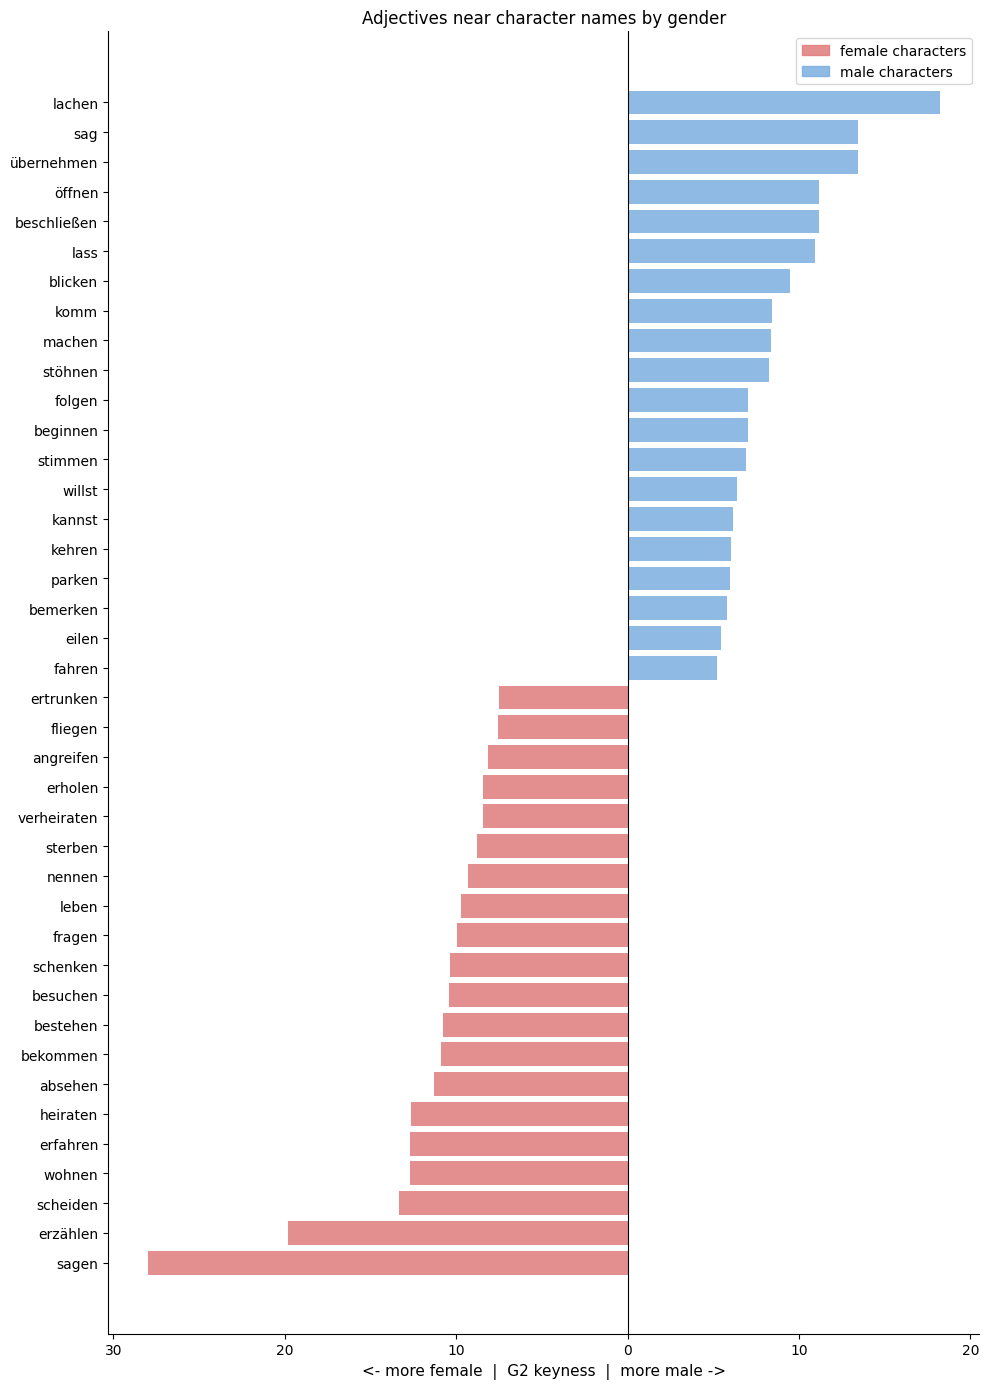

Saved adj_gender_window.png


In [22]:
# KI generiert
def plot_diverging(gender_comp_df, title, filename, top_n=20):
    if gender_comp_df.empty:
        print(f"Skipping plot '{title}' — no data.")
        return

    male_top   = gender_comp_df[gender_comp_df["direction"] == "male"].head(top_n).copy()
    female_top = gender_comp_df[gender_comp_df["direction"] == "female"].head(top_n).copy()

    if male_top.empty and female_top.empty:
        print(f"Skipping plot '{title}' — no male or female skewed adjectives found.")
        return

    male_top["G2_signed"]   =  male_top["G2"]
    female_top["G2_signed"] = -female_top["G2"]

    plot_df = pd.concat([
        female_top.sort_values("G2_signed"),
        male_top.sort_values("G2_signed"),
    ])

    colors = ["#e07b7b" if v < 0 else "#7baee0" for v in plot_df["G2_signed"]]

    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df) * 0.35)))
    ax.barh(plot_df["adjective"], plot_df["G2_signed"],
            color=colors, edgecolor="none", alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("<- more female  |  G2 keyness  |  more male ->", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{abs(x):.0f}"))
    male_patch   = mpatches.Patch(color="#7baee0", alpha=0.85, label="male characters")
    female_patch = mpatches.Patch(color="#e07b7b", alpha=0.85, label="female characters")
    ax.legend(handles=[female_patch, male_patch])
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    #plt.savefig(f"./outputs/{filename}", dpi=150)
    plt.show()
    print(f"Saved {filename}")


plot_diverging(significant,
               "Adjectives near character names by gender",
               "adj_gender_window.png")